<a href="https://colab.research.google.com/github/NOUBL-Badr/Projet_ML_IRIS/blob/main/Projet_IRIS_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projet Python sur dataset IRIS**

import de toutes les bibliothèques Python nécessaires pour le projet

In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modèles
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

# Évaluation et Optimisation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.datasets import load_iris

# Configuration visuelle
%matplotlib inline
sns.set(style="whitegrid")




*   Chargement du dataset
*   spliting des données




faire voir les premières lignes du dataset

In [ ]:
# Chargement du dataset Iris (similaire à vos exercices sur les attributs continus)
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split 80% Train / 30% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Taille de l'entraînement : {X_train.shape[0]} échantillons")
print(f"Taille de test : {X_test.shape[0]} échantillons")
print(X.head())

Taille de l'entraînement : 105 échantillons
Taille de test : 45 échantillons
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2




*   calcule du temps nécessaire pour chaque algorithme
*   plotting de la comparaison



                 Model  Accuracy  F1-Score  Time (s)
1            KNN (k=5)  0.977778  0.977753  0.002191
0  Logistic Regression  0.933333  0.933259  0.031627
5    Gradient Boosting  0.933333  0.933259  0.334422
4             AdaBoost  0.933333  0.933259  0.186071
3        Random Forest  0.911111  0.910714  0.190841
2  Decision Tree (d=4)  0.911111  0.911111  0.004371


/tmp/ipykernel_10865/402438696.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="F1-Score", data=comparison_df.sort_values(by="F1-Score", ascending=False), ax=ax, palette="magma")


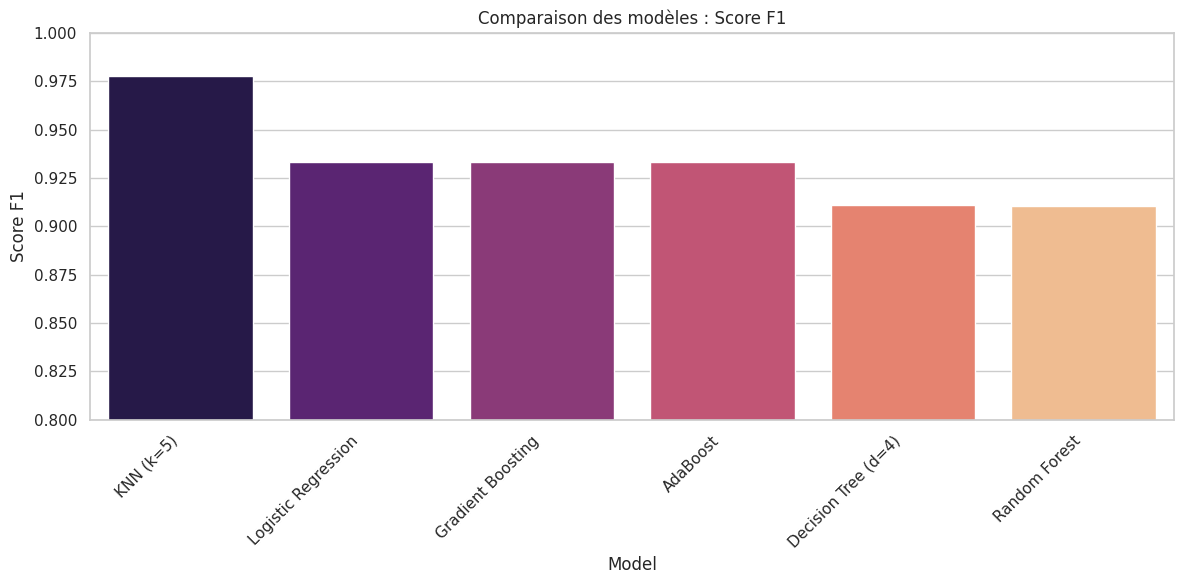

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree (d=4)": DecisionTreeClassifier(max_depth=4, criterion='entropy'),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100)
}

results = []

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "Time (s)": elapsed_time
    })

# Création du tableau comparatif
comparison_df = pd.DataFrame(results)
print(comparison_df.sort_values(by="Accuracy", ascending=False))
#plotting des résultats
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x="Model", y="F1-Score", data=comparison_df.sort_values(by="F1-Score", ascending=False), ax=ax, palette="magma")
ax.set_ylabel("Score F1")
ax.set_ylim(0.8, 1.0)
plt.title("Comparaison des modèles : Score F1")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Ajout de l'accuracy pour voir l'accuracy en fonction du temp d'executions

/tmp/ipykernel_10865/2645285703.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=comparison_df, ax=ax1, palette="viridis", alpha=0.7)


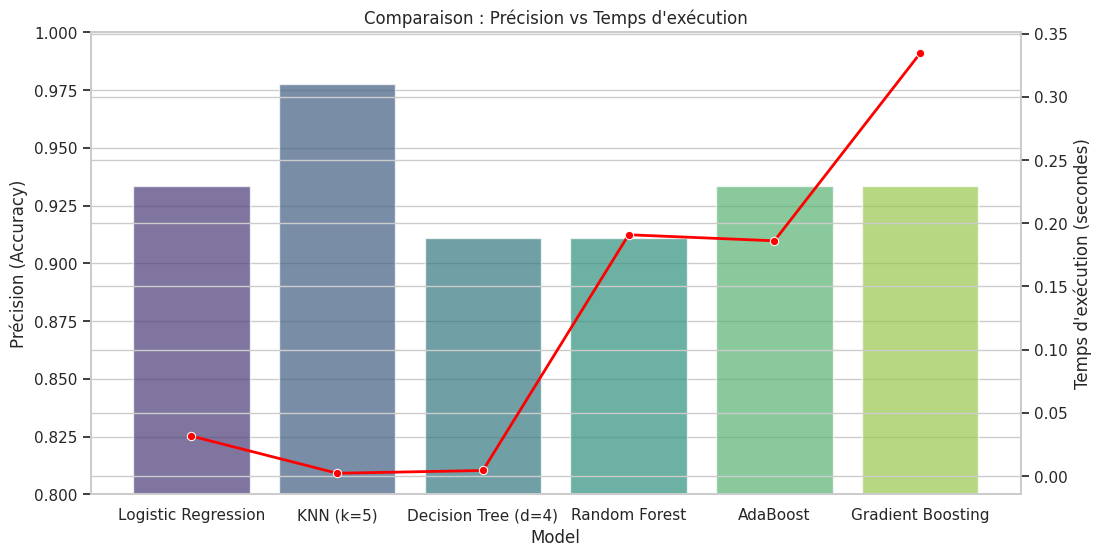

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barres pour l'Accuracy
sns.barplot(x="Model", y="Accuracy", data=comparison_df, ax=ax1, palette="viridis", alpha=0.7)
ax1.set_ylabel("Précision (Accuracy)")
ax1.set_ylim(0.8, 1.0)

# Ligne pour le temps d'exécution
ax2 = ax1.twinx()
sns.lineplot(x="Model", y="Time (s)", data=comparison_df, ax=ax2, color="red", marker="o", linewidth=2)
ax2.set_ylabel("Temps d'exécution (secondes)")

plt.title("Comparaison : Précision vs Temps d'exécution")
plt.show()

Analyse Biais Variance

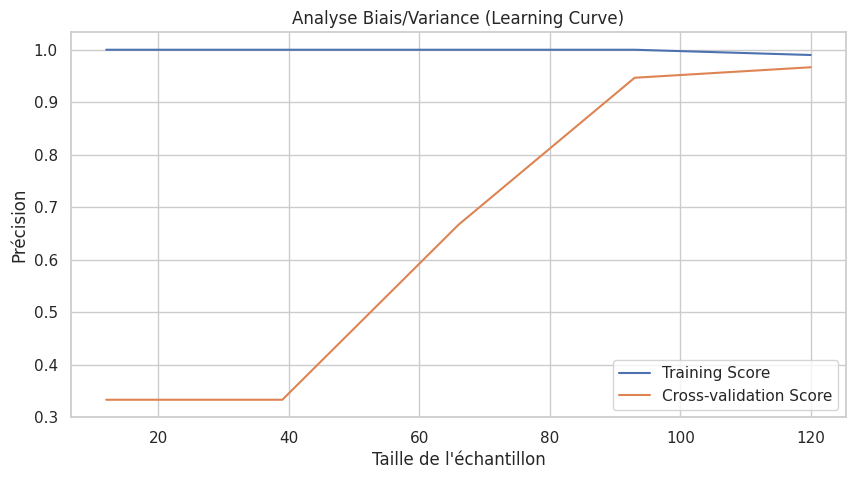

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    DecisionTreeClassifier(max_depth=4), X, y, cv=5, scoring='accuracy'
)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-validation Score')
plt.title("Analyse Biais/Variance (Learning Curve)")
plt.xlabel("Taille de l'échantillon")
plt.ylabel("Précision")
plt.legend()
plt.show()

affichage des règles de décision du modèle d'arbre de décision et visualisation de l'importance des caractéristiques pour le modèle de forêt aléatoire

--- RÈGLES INTERPRÉTABLES ---
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- sepal length (cm) <= 6.10
|   |   |   |--- sepal length (cm) <= 5.85
|   |   |   |   |--- class: 2
|   |   |   |--- sepal length (cm) >  5.85
|   |   |   |   |--- class: 1
|   |   |--- sepal length (cm) >  6.10
|   |   |   |--- class: 2



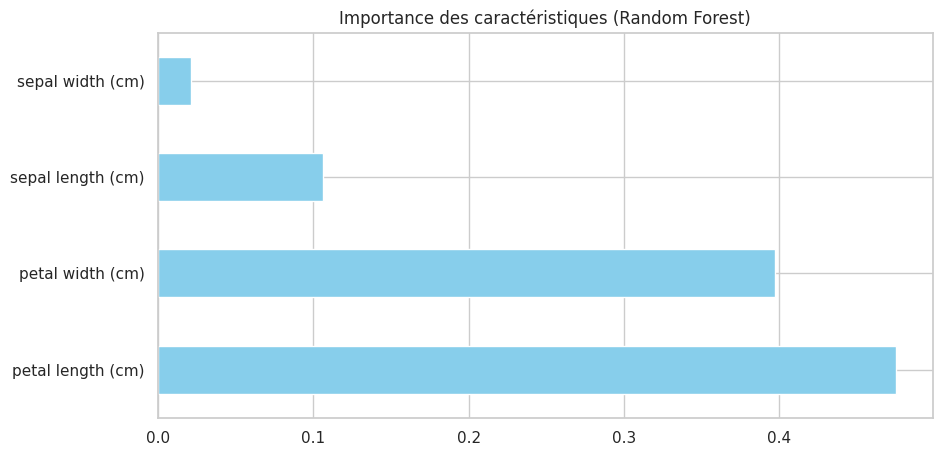

In [ ]:
# 1. Règles du Decision Tree
print("--- RÈGLES INTERPRÉTABLES ---")
print(export_text(models["Decision Tree (d=4)"], feature_names=list(data.feature_names)))

# 2. Importance des caractéristiques (Random Forest)
importances = models["Random Forest"].feature_importances_
feat_importance = pd.Series(importances, index=data.feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_importance.plot(kind='barh', color='skyblue')
plt.title("Importance des caractéristiques (Random Forest)")
plt.show()

Visialisation de l'arbre de décision (profondeur=4)

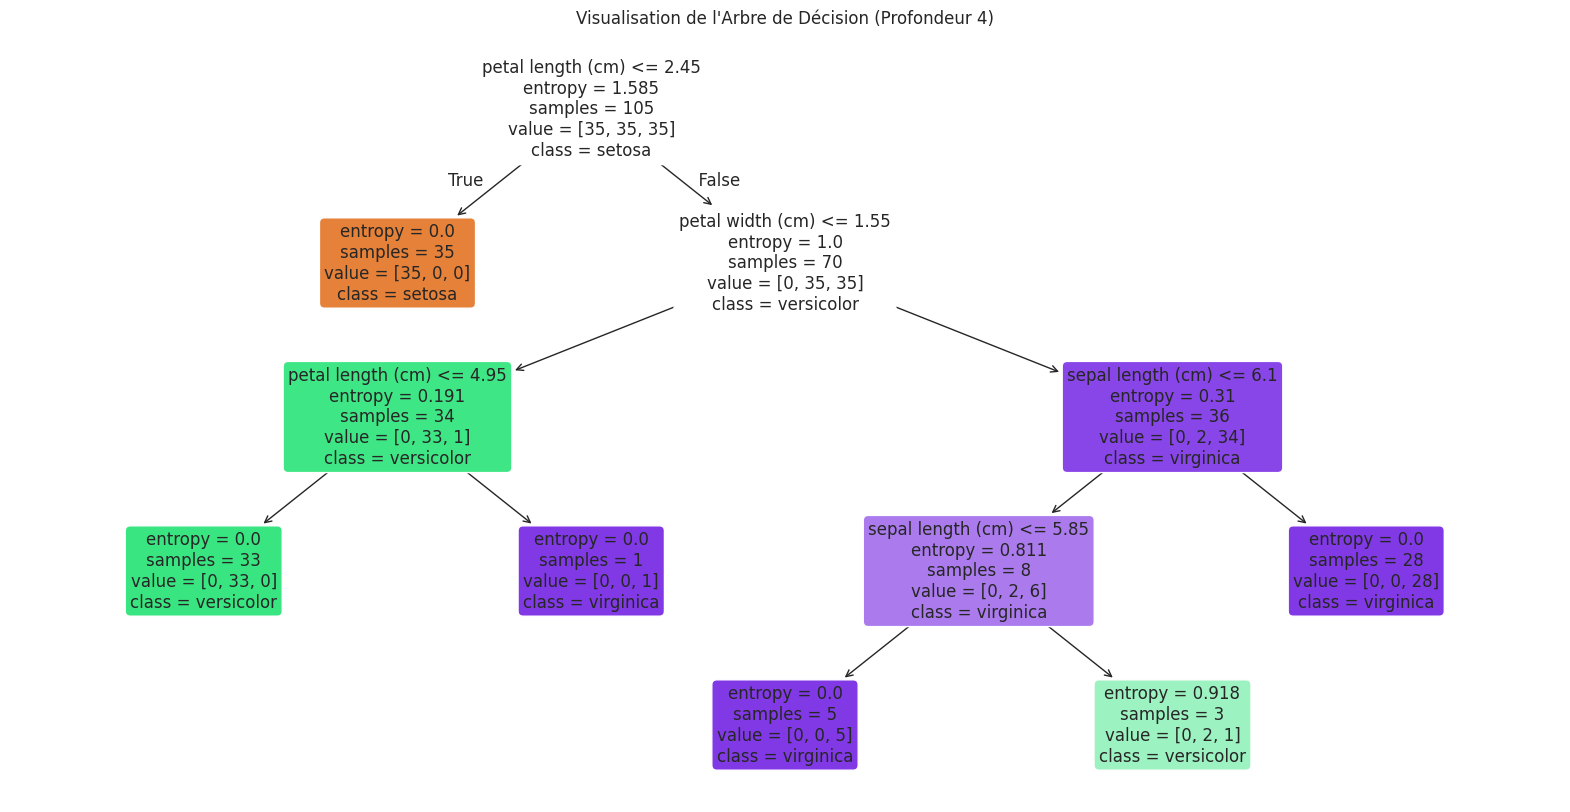

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(models["Decision Tree (d=4)"],
          feature_names=data.feature_names,
          class_names=data.target_names,
          filled=True, rounded=True, fontsize=12)
plt.title("Visualisation de l'Arbre de Décision (Profondeur 4)")
plt.show()

génèration et affichage de la matrice de confusion pour chaque modèle entraîné

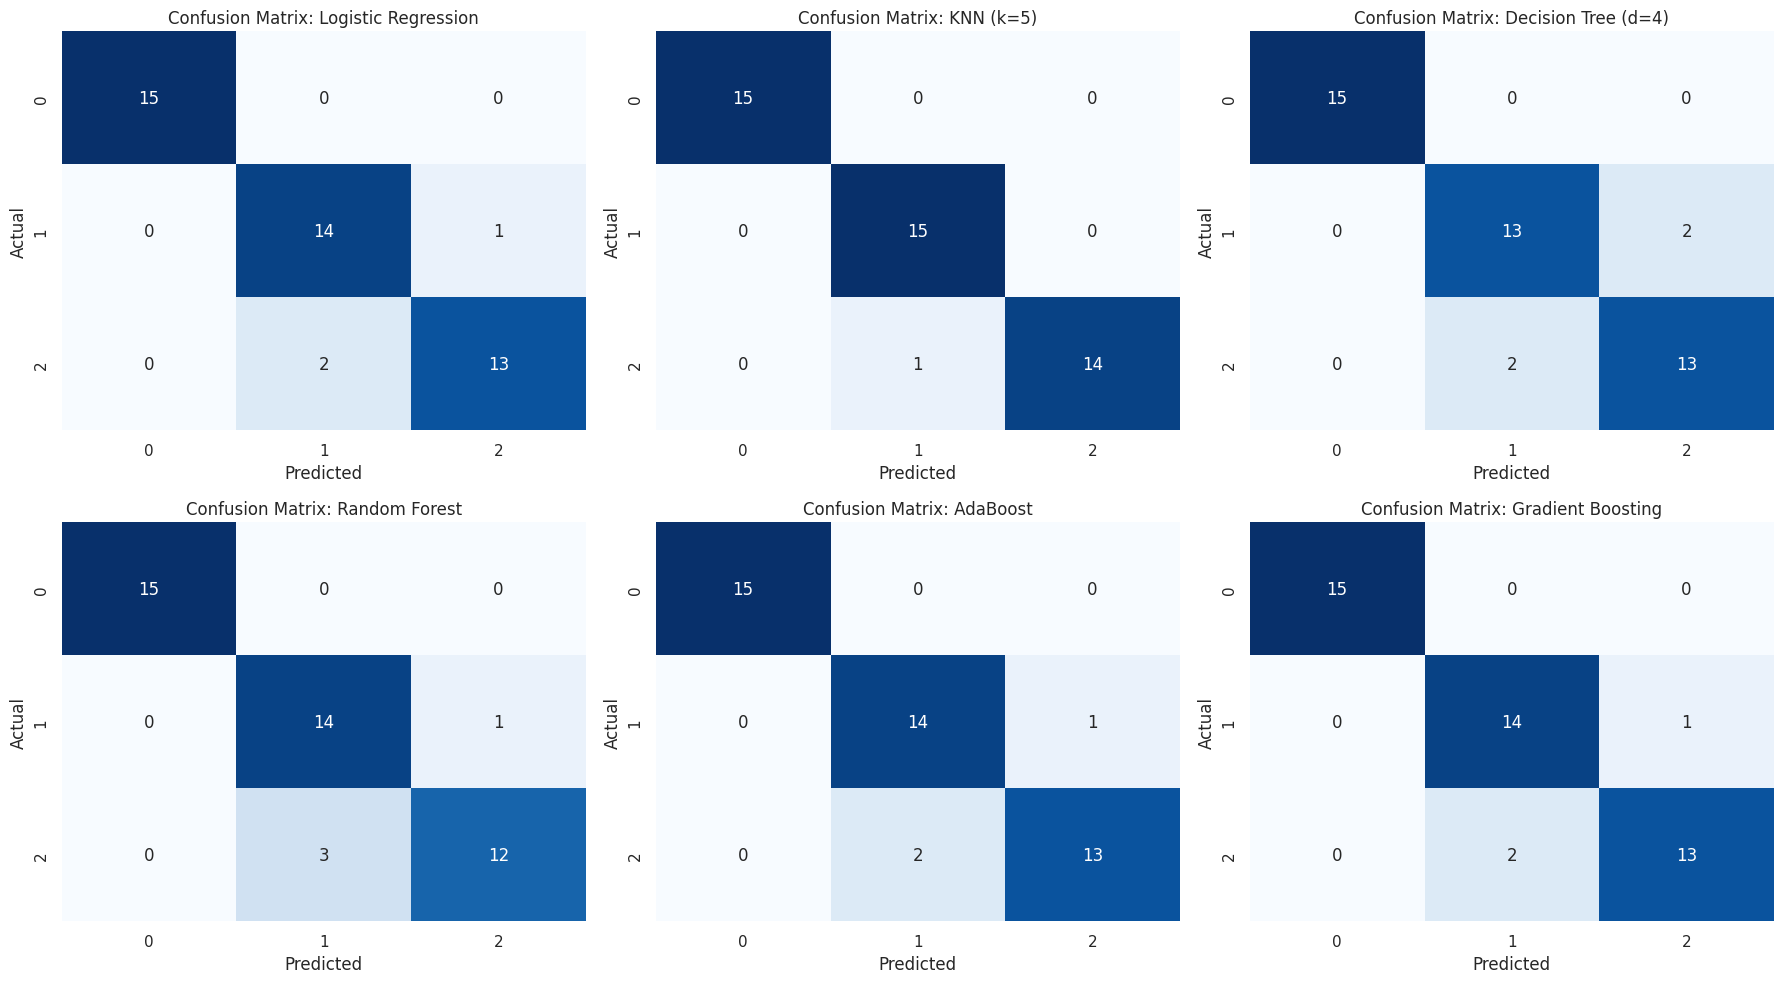

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Création et visualisation de la courbe ROC (Receiver Operating Characteristic) pour le modèle de régression logistique

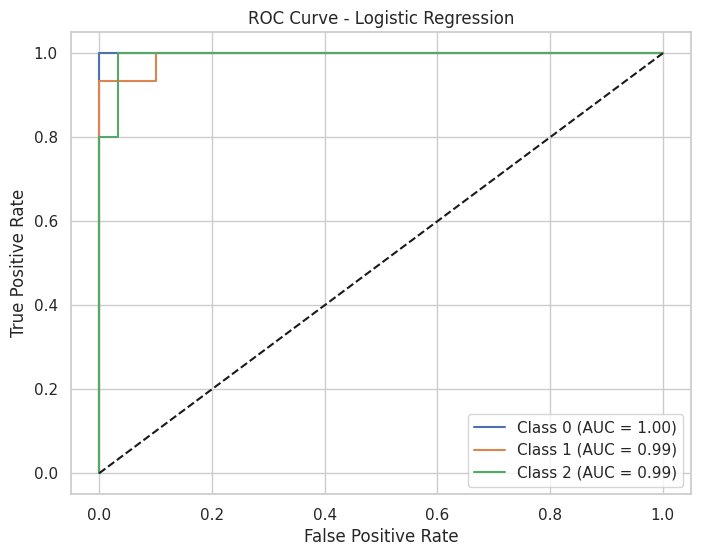

In [ ]:
# Note: This is for binary or one-vs-rest classification
from sklearn.preprocessing import label_binarize

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Predict probabilities
y_score = models["Logistic Regression"].predict_proba(X_test)

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc_score(y_test_bin[:, i], y_score[:, i]):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()